In [3]:
# Import libraries
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.mask import mask
import xarray as xr
import rioxarray
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import os

## --

In [8]:
# Open L10 band with xarray
band_path = 'datos\LC08_L2SP_229082_20190228_20200829_02_T1_ST_B10.TIF'
l8_band10 = xr.open_dataset(band_path, engine="rasterio", masked=True) # Setting masked=True converts NoData values automatically to NaN

# Visualize data attributes
l8_band10

<xarray.Dataset> Size: 239MB
Dimensions:      (band: 1, x: 7691, y: 7751)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 62kB 2.799e+05 2.799e+05 ... 5.106e+05 5.106e+05
  * y            (y) float64 62kB -3.396e+06 -3.396e+06 ... -3.629e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 238MB ...

In [41]:
l8_band10_sel.rio.crs.to_string()

'EPSG:32620'

In [83]:
# Read and evaluate cba vector data
vector_cba_path = 'datos\gran_cba2\gran_cba2.shp'
vector_cba = gpd.read_file(vector_cba_path).to_crs(l8_band10_sel.rio.crs.to_string()) # Define dataset crs for correct clipping

# Generate no urban area vector
vect_cbaNourb15 =  vector_cba.buffer(15000).unary_union
vect_cbaNourb7 =  vector_cba.buffer(7000).unary_union
vect_cbaNourb = vect_cbaNourb15.difference(vect_cbaNourb7)#.to_frame()#, align=True)

# Display geopandas dataset
#vector_cba

C:\Users\win10\AppData\Local\Temp\ipykernel_134856\1333838408.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  vect_cbaNourb15 =  vector_cba.buffer(15000).unary_union
C:\Users\win10\AppData\Local\Temp\ipykernel_134856\1333838408.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  vect_cbaNourb7 =  vector_cba.buffer(7000).unary_union


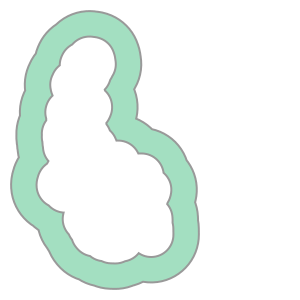

In [84]:
vect_cbaNourb

<Axes: >

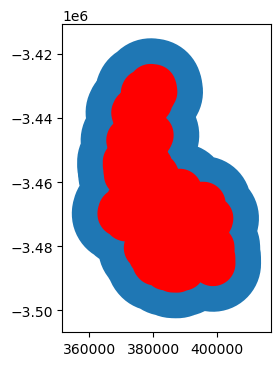

In [58]:
fig, ax = plt.subplots(figsize=(5, 4))
vect_cbaNourb15.plot(ax=ax)
vect_cbaNourb7.plot(ax=ax, color='red')

<Axes: >

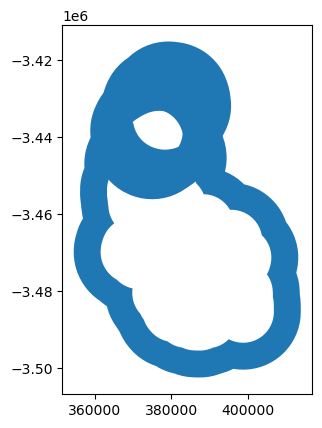

In [72]:
vect_cbaNourb15.to_frame().difference(vect_cbaNourb7.to_frame()).plot() 

In [36]:
# 5. Clip the dataset using the vector geometry
l810b_clip = l8_band10.rio.clip(vector_cba.geometry, drop=True) # Crops the dataset to the bounding box of the clipping geometry.

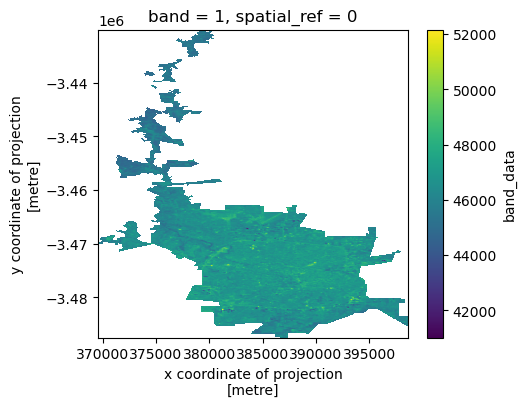

In [40]:
# Plot and display l8 band 10 data
fig, ax = plt.subplots(figsize=(5, 4))
l810b_clip.band_data.plot()

In [ ]:
# Compute l8 band 10 ST
l810b_clip.band_data